This tutorial covers end-to-end pseudobulk RNA-seq deconvolution in DECONVersation using Geneformer embeddings. It walks through constructing pseudobulk samples and their corresponding cell type proportion matrix from single-cell data, extracting embeddings from the pseudobulk and single-cell reference data, building signature matrices, and estimating cell type proportions with all solvers available in DECONVersation. Performance is assessed against the known proportions using RMSE and Pearson correlation. While this tutorial uses Geneformer, the workflow is fully compatible with Cell2Sentence, CellHermes and scGPT.

### Import libraries 

In [6]:
import sys
import os
import pandas as pd
import numpy as  np
import scanpy as sc
import deconversation
deconversation.__file__
from deconversation import embeddings, preprocessing, pseudobulk, deconvolution, visualization, evaluation

### Step 1: Load data

Here we use two single-cell datasets: one from 10x Genomics and the other from [Hao et al.](https://pubmed.ncbi.nlm.nih.gov/34062119/) The 10x data is used to create the pseudobulk samples, while the Hao data provides the signature matrix. We limit both datasets to the same four shared cell types. Since we are extracting geneformer embeddings, we ensure that ensembl ids are used..

In [2]:
# scRNAseq data (data for pseudobulking)
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmc5/10xpbmc5_id.h5ad"

# scRNAseq reference data 
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

In [3]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata.var.index = adata.var["gene_id"]
adata = adata[:, adata.var.index.notnull()]

In [4]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata_ref = adata_ref.copy()

# Remove unmapped genes
adata_ref.var.index = adata_ref.var["gene_id"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

### Step 2: Create pseudobulk

Here we use `pseudobulk.generate_pseudobulk()` to generate pseudobulk data from the single-cell reference. We generate 250 pseudobulk samples with target proportions bounded between 10% and 90%, limit each sample to 300 cells, and set `random_state=42` for reproducibility.

In [9]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = pseudobulk.generate_pseudobulk(adata = adata_ref,   
                                             cell_type_col = "broad_type",
                                             n_pseudobulks = 250,
                                             target_proportion_min = 0.1,
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 300, 
                                             random_state = 42 
                                            )

### Step 3: Extract geneformer embeddings on signature matrix and pseudobulk data

Here we use DECONVersation's `preprocessing.create_signature_matrix()` to build a signature matrix. This averages gene expression across cell types, producing a gene-by-cell-type table covering every unique cell type in the reference dataset.

In [13]:
# Create signature matrix from single cell data
sig_mat = preprocessing.create_signature_matrix(adata = adata_ref,
                                  sample_col = "batch", # sample id column
                                  cell_type_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/preprocessing.py:259: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


### Step 4: Extract Embeddings

Here we extract Geneformer embeddings from both the signature matrix and the generated pseudobulk data using Geneformer's zero-shot model from `ctheodoris/Geneformer`. Embedding extraction writes intermediate files, such as the tokenized dataset. We set `delete_temp_files=True` so these are removed automatically once extraction finishes. Set it to `False` if you want to keep them.

In [21]:
sig_mat_gf_embed = embeddings.extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    layer_to_quant = 18,
    delete_temp_files = True
)

In [22]:
pseudo_bulk_embed = embeddings.extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    layer_to_quant = 18,
    delete_temp_files = True
)

### Step 5: Run deconvolution

Here we run deconvolution with `deconvolution.run_all_deconv()`, which runs every solver available in DECONVersation. Deconvolution can also be run with `deconvolution.run_deconv()`, which uses NNLS as its default solver. DECONVersation currently supports `nnls`, `dwls` (solver only), `ridge`, `elasticnet`, and `nusvr`.

In [17]:
# Run deconvolution
results = deconvolution.run_all_deconv(bulk_df = pseudo_bulk_embed.T, 
                                       signature_df = sig_mat_gf_embed.T)

#### Step 6: Visualize results

After running `deconvolution.run_all_deconv()`, the results can be visualized with `visualization.visualize_solvers()`, which plots correlation and RMSE across all solvers used. Setting `level="cell_type"` reports correlation and RMSE per cell type instead.

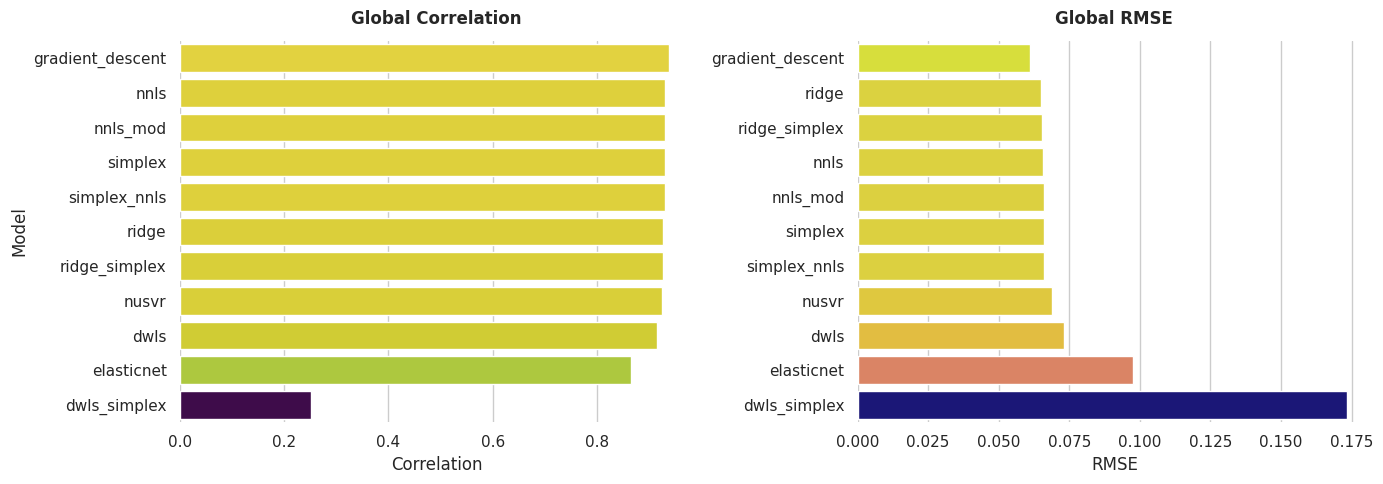

In [18]:
# Visualize results 
visualization.visualize_solvers(results, 
                  cell_prop, 
                  level=["global"])

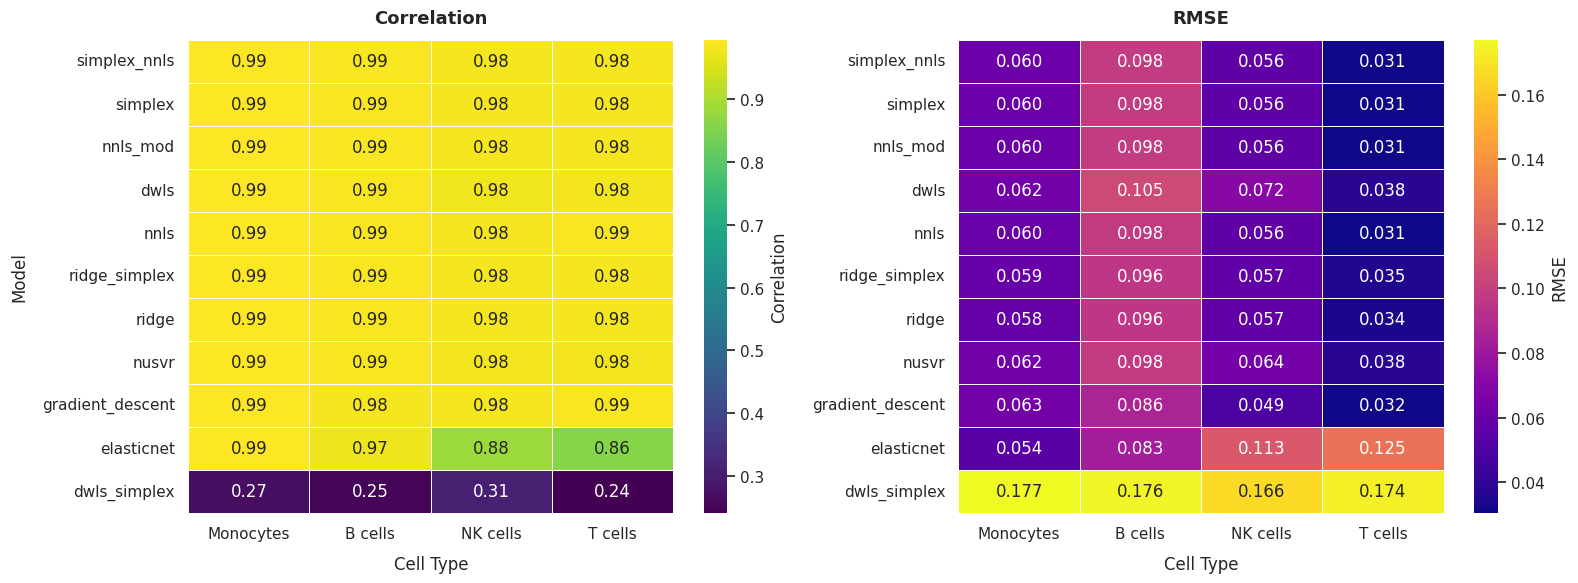

In [23]:
# Visualize results 
visualization.visualize_solvers(results, 
                  cell_prop, 
                  level=["cell_type"])

Here we plot predicted against true proportions with `visualization.plot_true_vs_predicted()`, using the NNLS results specifically. We set `stratify_by_celltype=False` to show all cell types on a single scatter plot; set it to `True` to get a separate plot per cell type.

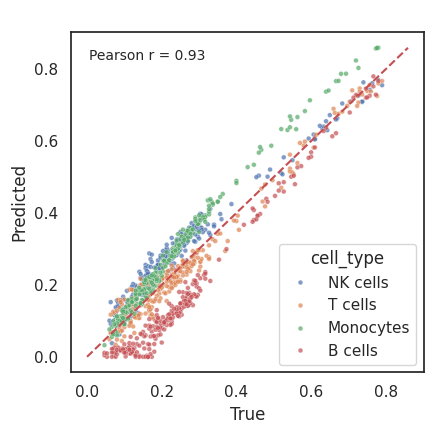

In [27]:
import matplotlib.pyplot as plt
plt.rcParams['axes.grid'] = False
visualization.plot_true_vs_predicted(y_true_df=cell_prop, 
                                     y_pred_df=results["nnls"], 
                                     stratify_by_celltype=False)

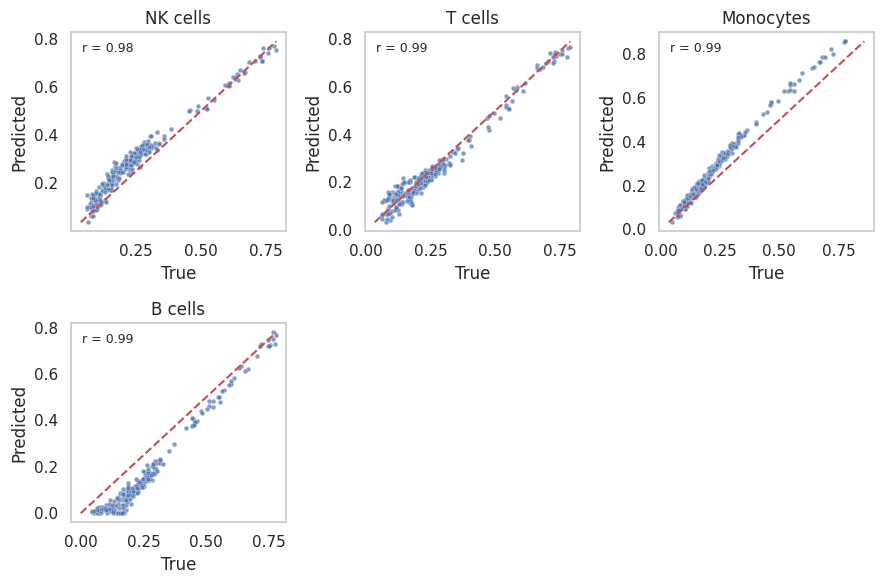

In [20]:
import matplotlib.pyplot as plt
plt.rcParams['axes.grid'] = False
visualization.plot_true_vs_predicted(y_true_df=cell_prop, 
                                     y_pred_df=results["nnls"], 
                                     stratify_by_celltype=True)